# Imaging

Based on MIT Vision Book Chapter 5 ("Imaging"), here are several Python examples that illustrate the main concepts: Lambertian reflection, Phong shading, perspective projection, orthographic projection, and pinhole camera image formation. [visionbook.mit.edu]



## Libraries

In [3]:
import numpy as np
import matplotlib.pyplot as plt


### 1. Lambertian Shading
The chapter introduces the Lambertian model:

```
I=a⋅L⋅(n⋅p)
```
where brightness depends on the angle between the surface normal and the incoming light direction.

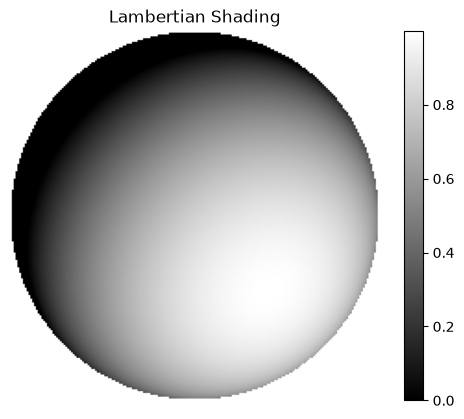

In [4]:
# Light direction (normalized)
light = np.array([0.5, 0.5, 1.0])
light = light / np.linalg.norm(light)

# Create hemisphere normals
x = np.linspace(-1, 1, 200)
y = np.linspace(-1, 1, 200)
X, Y = np.meshgrid(x, y)

mask = X**2 + Y**2 <= 1
Z = np.zeros_like(X)
Z[mask] = np.sqrt(1 - X[mask]**2 - Y[mask]**2)

# Surface normals
N = np.dstack((X, Y, Z))

# Lambertian intensity
I = np.maximum(np.sum(N * light, axis=2), 0)
I[~mask] = np.nan

plt.imshow(I, cmap="gray")
plt.title("Lambertian Shading")
plt.axis("off")
plt.colorbar()
plt.show()

### 2. Phong Specular Reflection
The chapter describes the Phong reflection model with a specular term: 

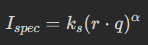

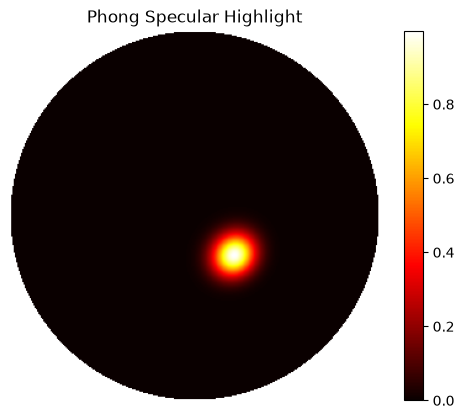

In [5]:
light = np.array([0.5, 0.5, 1.0])
light /= np.linalg.norm(light)

viewer = np.array([0, 0, 1])

x = np.linspace(-1, 1, 300)
y = np.linspace(-1, 1, 300)
X, Y = np.meshgrid(x, y)

mask = X**2 + Y**2 <= 1
Z = np.zeros_like(X)
Z[mask] = np.sqrt(1 - X[mask]**2 - Y[mask]**2)

N = np.dstack((X, Y, Z))

dot_nl = np.sum(N * light, axis=2)

R = 2 * dot_nl[..., None] * N - light

alpha = 40
specular = np.maximum(np.sum(R * viewer, axis=2), 0) ** alpha

specular[~mask] = np.nan

plt.imshow(specular, cmap="hot")
plt.title("Phong Specular Highlight")
plt.axis("off")
plt.colorbar()
plt.show()

### 3. Perspective Projection
The chapter derives the pinhole camera equations:

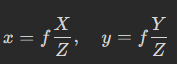

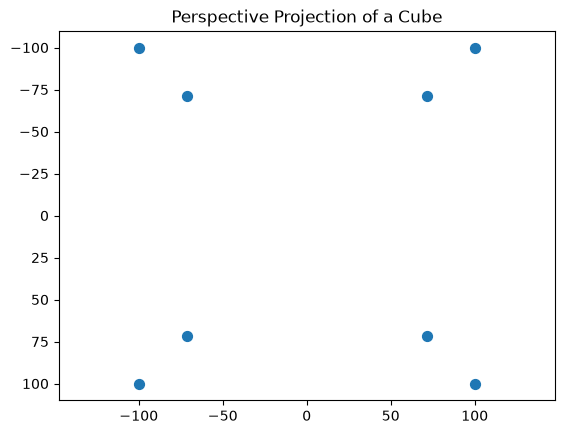

In [6]:
f = 500  # focal length

# Cube vertices
points = np.array([
    [-1,-1,5],
    [ 1,-1,5],
    [ 1, 1,5],
    [-1, 1,5],
    [-1,-1,7],
    [ 1,-1,7],
    [ 1, 1,7],
    [-1, 1,7]
])

X, Y, Z = points[:,0], points[:,1], points[:,2]

x = f * X / Z
y = f * Y / Z

plt.scatter(x, y, s=50)
plt.title("Perspective Projection of a Cube")
plt.gca().invert_yaxis()
plt.axis("equal")
plt.show()

### 4. Orthographic Projection
The chapter presents orthographic projection as:

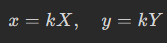

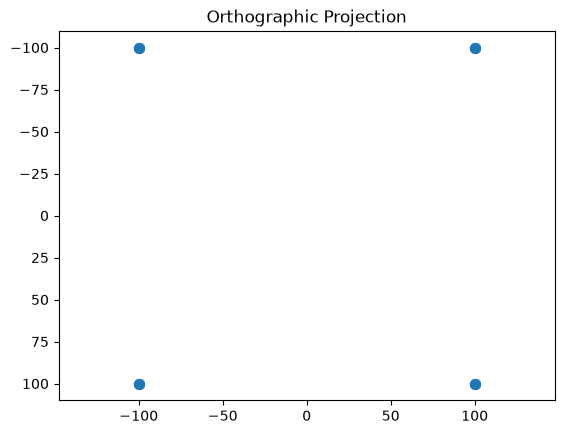

In [9]:
k = 100

points = np.array([
    [-1,-1,5],
    [ 1,-1,5],
    [ 1, 1,5],
    [-1, 1,5],
    [-1,-1,8],
    [ 1,-1,8],
    [ 1, 1,8],
    [-1, 1,8]
])

x = k * points[:,0]
y = k * points[:,1]

plt.scatter(x, y, s=50)
plt.title("Orthographic Projection")
plt.gca().invert_yaxis()
plt.axis("equal")
plt.show()

### 5. Perspective vs Orthographic Comparison

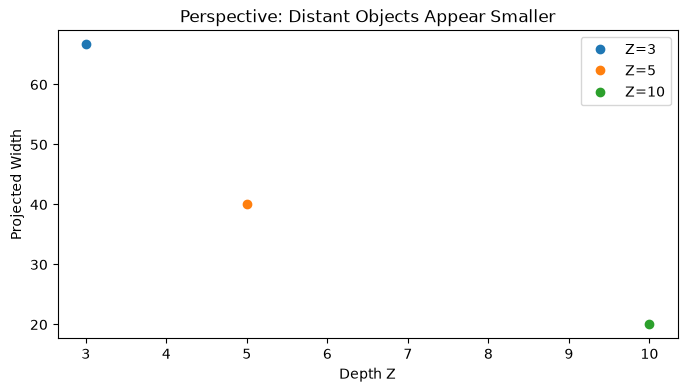

In [10]:
f = 200

depths = [3, 5, 10]

plt.figure(figsize=(8,4))

for z in depths:
    width = f * 1 / z
    plt.plot([z], [width], 'o', label=f'Z={z}')

plt.xlabel("Depth Z")
plt.ylabel("Projected Width")
plt.title("Perspective: Distant Objects Appear Smaller")
plt.legend()
plt.show()

### 6. Simple Pinhole Camera Renderer
A minimal implementation of a pinhole camera projection:

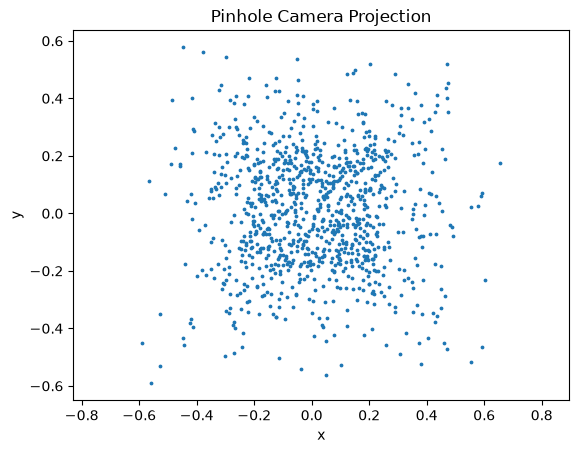

In [11]:
f = 1.0

# Random 3D points
N = 1000
X = np.random.uniform(-2, 2, N)
Y = np.random.uniform(-2, 2, N)
Z = np.random.uniform(3, 10, N)

x = f * X / Z
y = f * Y / Z

plt.scatter(x, y, s=3)
plt.title("Pinhole Camera Projection")
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.show()